In [47]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
from scipy.signal.windows import tukey
from pathlib import Path
from scipy.signal import welch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [48]:
def window_organ_signal(
    signal,
    sample_rate,
    return_info=False,
    search_step_ms=5.0,
    min_output_ms=80.0,
):
    """
    Individua automaticamente il tratto utile del segnale, lo ritaglia e applica
    una finestra di Tukey per evitare click e leakage.

    signal: Array numpy del segnale audio.
    sample_rate: Frequenza di campionamento.
    return_info: Se True, restituisce anche indici e parametri del taglio.
    search_step_ms: passo della ricerca (ms). Maggiore = piu veloce, meno preciso.
    min_output_ms: durata minima del segnale in uscita (ms).
    return: Segnale ritagliato e finestrato.
    """

    signal = np.asarray(signal)

    # Se il segnale e vuoto, restituisci subito (evita errori di indice).
    if signal.size == 0:
        if return_info:
            return signal, 0, 0, 0.0
        return signal

    # Normalizza in modo robusto anche per dtype diversi da int16.
    if np.issubdtype(signal.dtype, np.integer):
        if np.issubdtype(signal.dtype, np.unsignedinteger):
            info = np.iinfo(signal.dtype)
            mid = (info.max + 1) / 2.0
            signal = (signal.astype(np.float64) - mid) / mid
        else:
            info = np.iinfo(signal.dtype)
            denom = float(max(abs(info.min), info.max))
            signal = signal.astype(np.float64) / denom
    else:
        signal = signal.astype(np.float64, copy=False)

    # Calcola l'inviluppo del segnale (valore assoluto) e lo smussa con una media mobile.
    envelope = np.abs(signal)
    smooth_len = max(3, int(0.01 * sample_rate))
    smooth_kernel = np.ones(smooth_len, dtype=np.float64) / smooth_len
    smoothed = np.convolve(envelope, smooth_kernel, mode='same')

    # Soglia adattiva per individuare la parte attiva.
    peak_level = np.max(smoothed)
    noise_floor = np.percentile(smoothed, 20)
    base_threshold = max(noise_floor * 1.15, peak_level * 0.08)
    threshold = min(base_threshold, peak_level * 0.6)
    active_samples = np.flatnonzero(smoothed >= threshold)

    start_sample = 0
    end_sample = len(signal)

    if active_samples.size > 0:
        # Evita il vincolo fisso di 1s sui segnali corti.
        if len(signal) < sample_rate:
            minimum_start = int(0.10 * len(signal))
        else:
            minimum_start = int(1.0 * sample_rate)
        minimum_start = max(0, min(len(signal) - 1, minimum_start))

        stable_window = max(int(0.06 * sample_rate), 128)
        stable_window = min(stable_window, max(8, len(signal) // 3))
        end_guard = max(int(0.08 * sample_rate), stable_window)

        search_start = max(active_samples[0], minimum_start)
        max_center_start = int(0.65 * len(signal))
        max_valid_start = len(smoothed) - stable_window
        search_stop = min(active_samples[-1] + 1, max_valid_start, max_center_start)

        best_start = search_start
        best_score = np.inf

        if search_stop > search_start:
            search_span = max(1, search_stop - search_start)
            search_step = max(1, int((search_step_ms / 1000.0) * sample_rate))

            for idx in range(search_start, search_stop, search_step):
                segment = smoothed[idx:idx + stable_window]
                if segment.size < stable_window:
                    break

                segment_mean = np.mean(segment)
                if segment_mean < threshold:
                    continue

                segment_std = np.std(segment)
                base_score = segment_std / (segment_mean + 1e-12)

                # Penalita lieve per partenze troppo tarde.
                late_penalty = 0.12 * ((idx - search_start) / search_span)
                score = base_score + late_penalty

                if score < best_score:
                    best_score = score
                    best_start = idx

        start_sample = max(best_start, minimum_start)

        # Usa la parte attiva trovata per stimare la coda utile.
        end_candidate = int(active_samples[-1] + end_guard)
        end_sample = min(len(signal), max(start_sample + stable_window, end_candidate))

    if end_sample <= start_sample:
        trimmed_signal = signal[start_sample:]
    else:
        trimmed_signal = signal[start_sample:end_sample]

    # Fallback: se il taglio e troppo corto/vuoto, usa una finestra centrale minima.
    min_output_samples = max(32, int((min_output_ms / 1000.0) * sample_rate))
    if len(trimmed_signal) < min_output_samples:
        center = len(signal) // 2
        half = min_output_samples // 2
        lo = max(0, center - half)
        hi = min(len(signal), lo + min_output_samples)
        lo = max(0, hi - min_output_samples)
        trimmed_signal = signal[lo:hi]
        start_sample, end_sample = lo, hi

    if len(trimmed_signal) == 0:
        if return_info:
            return trimmed_signal, start_sample, end_sample, 0.0
        return trimmed_signal

    # Sceglie automaticamente la larghezza del fade in base alla durata del taglio.
    fade_samples = max(1, int(0.02 * sample_rate))
    fade_fraction = min(0.2, max(0.02, (2 * fade_samples) / len(trimmed_signal)))
    win = tukey(len(trimmed_signal), alpha=fade_fraction)

    # Applica la finestra e restituisce direttamente il segnale ritagliato.
    windowed_signal = trimmed_signal * win
    if return_info:
        return windowed_signal, start_sample, end_sample, fade_fraction
    return windowed_signal

In [ ]:
def analizza_nota_welch_mono(file_path, nperseg=8192, plot=True, xlim_hz=5000):
    """
    Converte in mono, ritaglia e calcola lo spettro mediato con Welch.

    file_path: percorso del file audio.
    nperseg: lunghezza segmento Welch (viene adattata automaticamente se troppo grande).
    plot: se True mostra il grafico PSD.
    xlim_hz: limite superiore asse X nel grafico.
    """
    # 1. Caricamento
    samplerate, data = wavfile.read(file_path)
    data = np.asarray(data)

    # 2. Normalizzazione robusta per tutti i tipi interi (signed/unsigned)
    if np.issubdtype(data.dtype, np.integer):
        if np.issubdtype(data.dtype, np.unsignedinteger):
            info = np.iinfo(data.dtype)
            mid = (info.max + 1) / 2.0
            data = (data.astype(np.float64) - mid) / mid
        else:
            info = np.iinfo(data.dtype)
            denom = float(max(abs(info.min), info.max))
            data = data.astype(np.float64) / denom
    else:
        data = data.astype(np.float64, copy=False)

    # 3. Conversione in MONO (media dei canali)
    if data.ndim > 1:
        signal_mono = np.mean(data, axis=1)
    else:
        signal_mono = data

    # 4. Ritaglio e windowing
    signal_cut = window_organ_signal(signal_mono, samplerate)

    # 5. Guardie su segnali troppo corti/vuoti
    if signal_cut.size < 8:
        if plot:
            print(f"Segnale troppo corto dopo il taglio per {Path(file_path).name}: {signal_cut.size} campioni")
        return np.array([]), np.array([])

    nperseg_eff = min(int(nperseg), int(signal_cut.size))
    if nperseg_eff < 8:
        if plot:
            print(f"nperseg_eff troppo piccolo per {Path(file_path).name}: {nperseg_eff}")
        return np.array([]), np.array([])

    # 6. Calcolo PSD con Welch (parametri espliciti e stabili)
    noverlap_eff = nperseg_eff // 2
    freqs, psd = welch(
        signal_cut,
        fs=samplerate,
        window='hann',
        nperseg=nperseg_eff,
        noverlap=noverlap_eff,
        detrend='constant',
    )

    # 7. Plotting opzionale
    if plot and freqs.size > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(freqs, 10 * np.log10(psd + 1e-12), color='forestgreen')
        plt.title(f"Spettro di Potenza (Mono) - {Path(file_path).name}")
        plt.xlabel('Frequenza (Hz)')
        plt.ylabel('Potenza (dB/Hz)')
        plt.xlim(0, xlim_hz)

        # Griglia in X: major ogni 300 Hz
        ax = plt.gca()
        ax.set_xticks(np.arange(0, xlim_hz + 1, 300))
        ax.grid(True, which='major', alpha=0.35)

        plt.tight_layout()
        plt.show()

    return freqs, psd

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_63656/2854580780.py:4: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(sample_file)


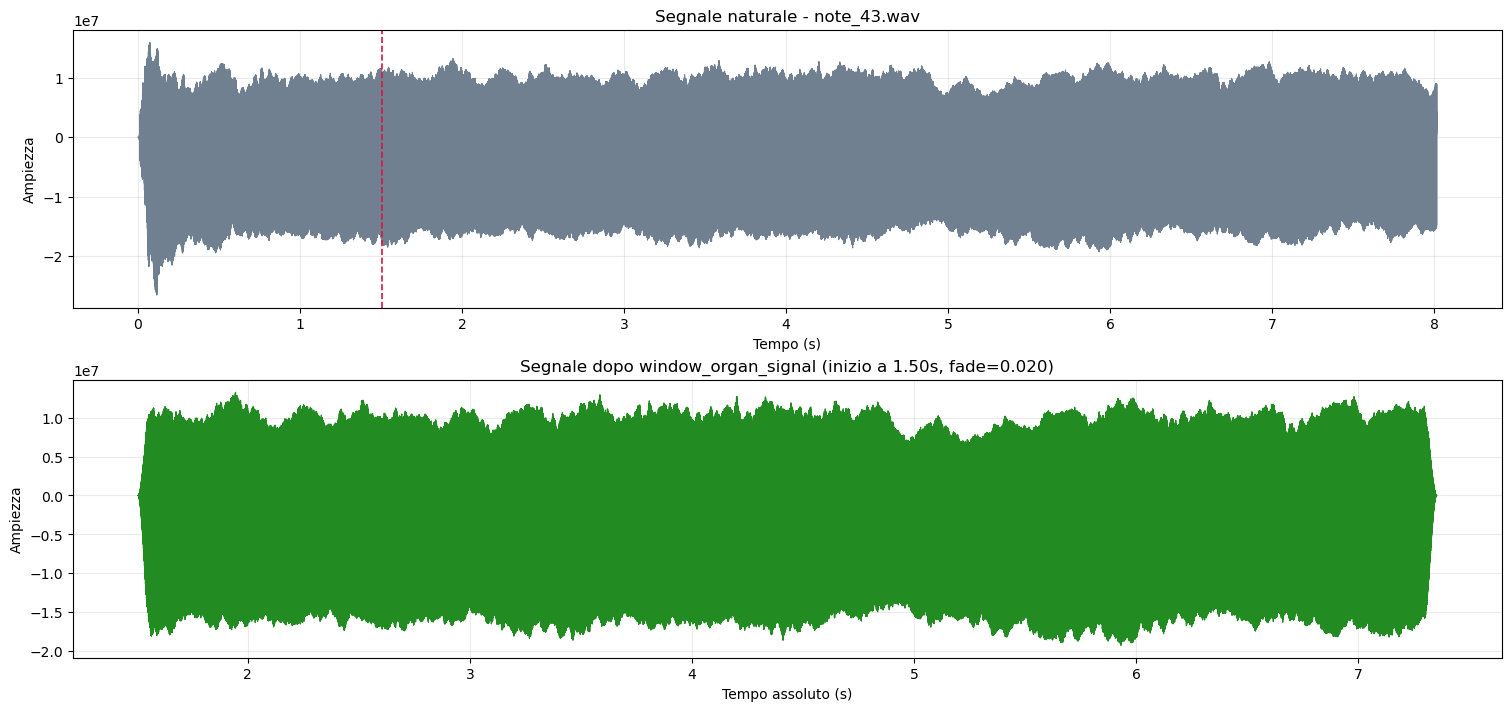

In [50]:
# Esempio visivo: confronto tra segnale naturale e segnale ritagliato/finestrato
sample_file = Path('data/note_43.wav')

samplerate, data = wavfile.read(sample_file)
if data.dtype == np.int16:
    data = data / 32768.0

if len(data.shape) > 1:
    signal_mono = np.mean(data, axis=1)
else:
    signal_mono = data

windowed_signal, start_idx, end_idx, fade_fraction = window_organ_signal(
    signal_mono, samplerate, return_info=True
)

raw_time = np.arange(len(signal_mono)) / samplerate
windowed_time = (start_idx + np.arange(len(windowed_signal))) / samplerate

fig, axes = plt.subplots(2, 1, figsize=(15, 7), constrained_layout=True)

axes[0].plot(raw_time, signal_mono, color='slategray', linewidth=0.8)
axes[0].axvline(start_idx / samplerate, color='crimson', linestyle='--', linewidth=1.2)
axes[0].set_title(f'Segnale naturale - {sample_file.name}')
axes[0].set_xlabel('Tempo (s)')
axes[0].set_ylabel('Ampiezza')
axes[0].grid(True, alpha=0.25)

axes[1].plot(windowed_time, windowed_signal, color='forestgreen', linewidth=0.9)
axes[1].set_title(
    f'Segnale dopo window_organ_signal (inizio a {start_idx / samplerate:.2f}s, fade={fade_fraction:.3f})'
)
axes[1].set_xlabel('Tempo assoluto (s)')
axes[1].set_ylabel('Ampiezza')
axes[1].grid(True, alpha=0.25)

plt.show()

## Trova la frequanza fondamentale anche se manca con MCD

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_63656/1136274059.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


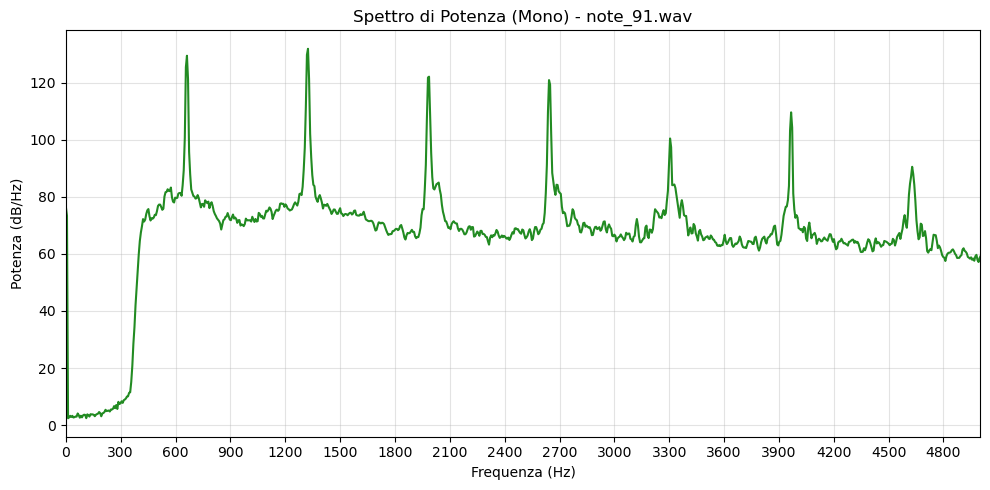

La frequenza fondamentale stimata è: 662.11 Hz


In [51]:
def mcd_euclide_float(a, b, tolleranza=2.0):
    """
    Versione dell'algoritmo di Euclide per numeri float.
    Si ferma quando il resto è inferiore alla tolleranza.
    """
    while b > tolleranza:
        a, b = b, a % b
    return a

def identifica_f0_euclide(freqs, psd, num_picchi=5):
    """
    Identifica la fondamentale calcolando il Massimo Comun Divisore 
    tra le frequenze dei picchi principali usando il metodo di Euclide.
    """
    # 1. Trova i picchi principali (semplice ricerca locale)
    soglia = np.max(psd) * 0.1
    picchi_idx = []
    for i in range(1, len(psd) - 1):
        if psd[i] > psd[i-1] and psd[i] > psd[i+1] and psd[i] > soglia:
            picchi_idx.append(i)
    
    f_picchi = freqs[picchi_idx[:num_picchi]]
    
    if len(f_picchi) < 2:
        return f_picchi[0] if len(f_picchi) == 1 else 0

    # 2. Applichiamo Euclide in cascata sui picchi trovati
    # Calcoliamo l'MCD tra il primo e il secondo, poi il risultato col terzo, ecc.
    # Usiamo una tolleranza legata alla risoluzione della FFT (es. 2-5 Hz)
    res_mcd = f_picchi[0]
    for i in range(1, len(f_picchi)):
        res_mcd = mcd_euclide_float(res_mcd, f_picchi[i], tolleranza=2.5)
    
    # 3. Controllo di plausibilità
    # A volte l'MCD può risultare in una sottarmonica (es. f0/2). 
    # Se il valore è troppo basso (es. < 15Hz per un organo), potrebbe esserci un errore.
    
    return res_mcd


freqs, psd = analizza_nota_welch_mono('data/note_91.wav')
f0 = identifica_f0_euclide(freqs, psd)
print(f"La frequenza fondamentale stimata è: {f0:.2f} Hz")

## Analisi di tutte le note: DOVREMMO USARE WELCH COME PRIMA?

In [52]:
def process_organ_notes(folder_path):
    
    data_dir = Path(folder_path)
    files = sorted(data_dir.glob('note_*.wav'))
    results = {}

    for file_path in files:
        samplerate, data = wavfile.read(file_path)
        
        # 1. Normalizzazione e gestione Stereo -> Mono
        if data.dtype == np.int16:
            data = data / 32768.0
            
        if len(data.shape) > 1:
            signal = np.mean(data, axis=1)
        else:
            signal = data

        # 2. CHIAMATA ALLA FUNZIONE ESTERNA
        # La funzione decide da sola quanto ritagliare e quanto sfumare i bordi.
        final_signal = window_organ_signal(signal, samplerate)
        
        # 3. FFT e Analisi
        #n = len(final_signal)
        #fft_values = np.fft.fft(final_signal)
        #frequencies = np.fft.fftfreq(n, d=1/samplerate)[:n//2] # prendo solo la metà positiva perchè quella negativa è speculare (vale per segnali reali )
        #power_spectrum = np.abs(fft_values[:n//2])**2
        frequencies, power_spectrum = welch(final_signal, fs=samplerate, nperseg=8192) 
        fundamental_freq = identifica_f0_euclide(frequencies, power_spectrum)
        
        results[file_path.name] = {
            'freq': frequencies,
            'psd': power_spectrum,
            'rate': samplerate,
            'f0': fundamental_freq
        }
        #print(f"Elaborato: {file_path.name}")

    return results

results = process_organ_notes('data/')

print(f'Number of files processed: {len(results)}')
print(f'Check psd length: {len(results["note_1.wav"]["psd"])}')
print(f'Sample rate: {results["note_1.wav"]["rate"]}')
print(f'Second file fundamental frequency: {results["note_2.wav"]["f0"]:.0f} Hz')

/var/folders/xt/7jwm3jpn57sgpkrqpy1g1bph0000gn/T/ipykernel_63656/2112978158.py:8: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(file_path)


Number of files processed: 280
Check psd length: 4097
Sample rate: 48000
Second file fundamental frequency: 1482 Hz


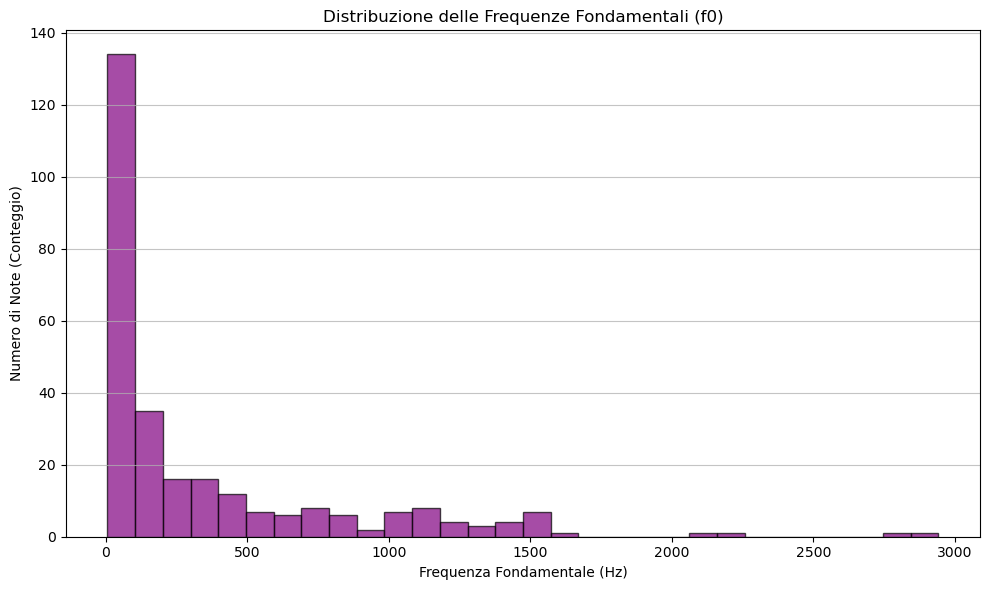

In [53]:
# Estrai tutte le frequenze fondamentali, ignorando eventuali valori a 0 (note non identificate)
f0_values = [data['f0'] for data in results.values() if data['f0'] > 0]

# Crea l'istogramma
plt.figure(figsize=(10, 6))
plt.hist(f0_values, bins=30, color='purple', edgecolor='black', alpha=0.7)

# Personalizza il grafico
plt.title('Distribuzione delle Frequenze Fondamentali (f0)')
plt.xlabel('Frequenza Fondamentale (Hz)')
plt.ylabel('Numero di Note (Conteggio)')
plt.grid(axis='y', alpha=0.75)

# Mostra il grafico
plt.tight_layout()
plt.show()

# sarebbe bello avere delle frequenze di riferimento per le note musicali e vedere se le frequenze fondamentali identificate si allineano con queste frequenze teoriche. 
# Potremmo anche colorare l'istogramma in base alla vicinanza alle frequenze di riferimento per evidenziare quali note sono più rappresentate.

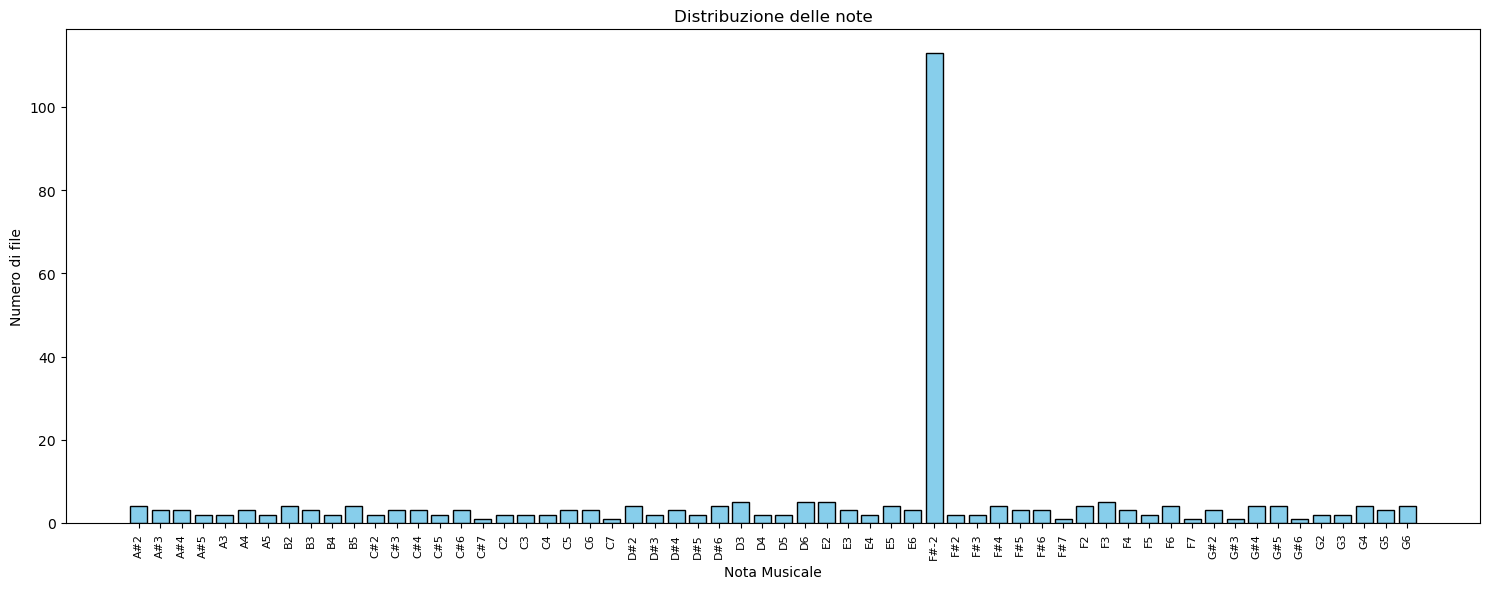

In [54]:
f0_array = np.array(f0_values)  
# 1. Converti in numeri MIDI 
midi_notes = 69 + 12 * np.log2(f0_array / 440) 
# 2. Definisci i nomi delle note 
note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'] 
# 3. Funzione per ottenere il nome con l'ottava (es. 60 -> C4) 
def midi_to_name(n): 
    n = int(round(n)) 
    return f"{note_names[n % 12]}{n // 12 - 1}" 
    
# 4. Prepara i dati per l'istogramma  
labels = [midi_to_name(n) for n in midi_notes] 
unique_labels, counts = np.unique(labels,return_counts=True)  

# 1. Crea una figura molto larga (es. 15 pollici di larghezza, 6 di altezza) 
plt.figure(figsize=(15, 6)) 
# 2. Crea il grafico a barre 
plt.bar(unique_labels, counts, color='skyblue', edgecolor='black') 
# 3. Configura le etichette dell'asse X 
plt.xticks( rotation=90, fontsize=8, ha='center') 
plt.xlabel('Nota Musicale') 
plt.ylabel('Numero di file') 
plt.title('Distribuzione delle note') 
# 4. Ottimizza i margini per non tagliare le etichette in basso
plt.tight_layout() 
plt.show()  

# Estraiamo le ampiezze degli overtoni (armoniche)

In [55]:
def estrai_ampiezze_armoniche(freqs, psd, f0, num_armoniche):
    """Estrae l'ampiezza delle prime N armoniche e le normalizza."""
    armoniche = []
    
    for i in range(1, num_armoniche + 1):
        f_target = f0 * i
        # Trova l'indice dell'array delle frequenze più vicino al multiplo esatto
        idx = np.argmin(np.abs(freqs - f_target))
        armoniche.append(psd[idx])
        
    armoniche = np.array(armoniche)
    
    # NORMALIZZAZIONE FONDAMENTALE: 
    # Dividiamo tutto per l'ampiezza della prima armonica (la f0). 
    # Così confrontiamo il "timbro" (le proporzioni) e non il volume assoluto della registrazione!
    if armoniche[0] > 0:
        armoniche = armoniche / armoniche[0] 
        
    return armoniche

## K-means

In [56]:
# 1. Creiamo la matrice X delle features: ogni riga è una nota, 
# ogni colonna è l'ampiezza normalizzata(ridpetto all'ampiezza della sua f0) di un'armonica (es. 2a, 3a, 4a, 5a).
X = []
nomi_file = []

for file_name, data in results.items():
    if data['f0'] > 0: # Procediamo solo se la nota è stata identificata
        # Estraiamo le prime 5 armoniche
        features = estrai_ampiezze_armoniche(data['freq'], data['psd'], data['f0'], num_armoniche=5)
        
        # Ignoriamo la prima colonna (che ora vale sempre 1.0 per via della normalizzazione)
        # e usiamo le armoniche dalla 2 alla 5 come "coordinate" del nostro suono si possono usare anche più dimenssioni (tipo 10 armoniche)
        X.append(features[1:]) 
        nomi_file.append(file_name)

X = np.array(X)

# 2. Applichiamo il K-Means
# Scegli il numero di cluster (K). Se sai di avere 3 registri diversi nel dataset, metti 3.
NUMERO_REGISTRI = 5
kmeans = KMeans(n_clusters=NUMERO_REGISTRI, random_state=42)

# Addestriamo il modello e otteniamo le etichette (i gruppi assegnati)
labels = kmeans.fit_predict(X)

# 3. Stampiamo i risultati
print("\n--- RISULTATI CLUSTERING ---")
for name, label in zip(nomi_file, labels):
    print(f"File: {name} -> Assegnato al Cluster (Registro): {label}")


--- RISULTATI CLUSTERING ---
File: note_1.wav -> Assegnato al Cluster (Registro): 4
File: note_10.wav -> Assegnato al Cluster (Registro): 1
File: note_100.wav -> Assegnato al Cluster (Registro): 1
File: note_101.wav -> Assegnato al Cluster (Registro): 1
File: note_102.wav -> Assegnato al Cluster (Registro): 1
File: note_103.wav -> Assegnato al Cluster (Registro): 1
File: note_104.wav -> Assegnato al Cluster (Registro): 1
File: note_105.wav -> Assegnato al Cluster (Registro): 1
File: note_106.wav -> Assegnato al Cluster (Registro): 1
File: note_107.wav -> Assegnato al Cluster (Registro): 1
File: note_108.wav -> Assegnato al Cluster (Registro): 1
File: note_109.wav -> Assegnato al Cluster (Registro): 2
File: note_11.wav -> Assegnato al Cluster (Registro): 1
File: note_110.wav -> Assegnato al Cluster (Registro): 1
File: note_111.wav -> Assegnato al Cluster (Registro): 1
File: note_112.wav -> Assegnato al Cluster (Registro): 1
File: note_113.wav -> Assegnato al Cluster (Registro): 1
File:

In [57]:
results_df = pd.DataFrame({'File': nomi_file, 'Cluster': labels})
for i in range(NUMERO_REGISTRI):
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}):")
    print(results_df[results_df['Cluster'] == i]['File'].values)


Note nel Cluster 0 (Probabile Registro 0):
['note_149.wav' 'note_159.wav']

Note nel Cluster 1 (Probabile Registro 1):
['note_10.wav' 'note_100.wav' 'note_101.wav' 'note_102.wav' 'note_103.wav'
 'note_104.wav' 'note_105.wav' 'note_106.wav' 'note_107.wav'
 'note_108.wav' 'note_11.wav' 'note_110.wav' 'note_111.wav' 'note_112.wav'
 'note_113.wav' 'note_114.wav' 'note_115.wav' 'note_116.wav'
 'note_117.wav' 'note_118.wav' 'note_119.wav' 'note_12.wav' 'note_120.wav'
 'note_121.wav' 'note_122.wav' 'note_123.wav' 'note_124.wav'
 'note_125.wav' 'note_126.wav' 'note_127.wav' 'note_128.wav'
 'note_129.wav' 'note_13.wav' 'note_130.wav' 'note_131.wav' 'note_132.wav'
 'note_133.wav' 'note_134.wav' 'note_135.wav' 'note_136.wav'
 'note_137.wav' 'note_138.wav' 'note_139.wav' 'note_14.wav' 'note_140.wav'
 'note_141.wav' 'note_142.wav' 'note_143.wav' 'note_144.wav'
 'note_145.wav' 'note_146.wav' 'note_147.wav' 'note_148.wav' 'note_15.wav'
 'note_150.wav' 'note_151.wav' 'note_152.wav' 'note_153.wav'
 'n

## K-means con PCD

In [58]:
# Supponiamo che 'X' sia la tua matrice con 5 armoniche (f0, f1, f2, f3, f4)
# X = np.array(...) 

# 1. Standardizzazione (Fondamentale per la PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Applicazione della PCA per ridurre a 2 dimensioni
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Esecuzione del K-Means sui dati "schiacciati" dalla PCA
N_CLUSTERS_PCA = 5
kmeans = KMeans(n_clusters=N_CLUSTERS_PCA, random_state=42)
labels = kmeans.fit_predict(X_pca) # o su X_scaled, il risultato visivo sarà coerente

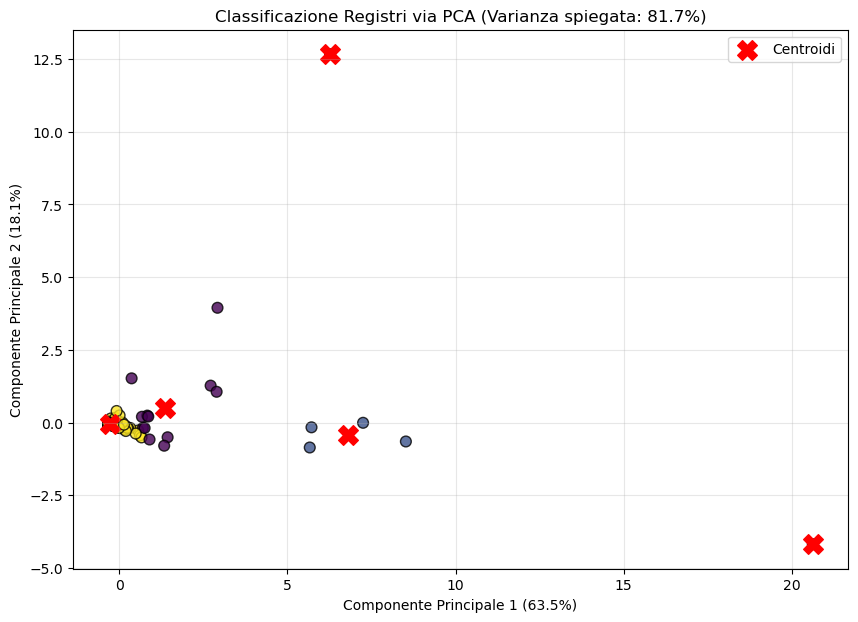

In [59]:
plt.figure(figsize=(10, 7))

# Plot dei punti
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=60, alpha=0.8, edgecolors='k')

# Plot dei centroidi
centroids_pca = kmeans.cluster_centers_
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=200, c='red', label='Centroidi')

# Calcolo della varianza spiegata (per capire quanto è accurato il riassunto)
var_exp = pca.explained_variance_ratio_
plt.title(f"Classificazione Registri via PCA (Varianza spiegata: {sum(var_exp)*100:.1f}%)")
plt.xlabel(f"Componente Principale 1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"Componente Principale 2 ({var_exp[1]*100:.1f}%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
results_df = pd.DataFrame({'File': nomi_file, 'Cluster': labels})
for i in range(N_CLUSTERS_PCA):
    print(f"\nNote nel Cluster {i} (Probabile Registro {i}):")
    print(results_df[results_df['Cluster'] == i]['File'].values)


Note nel Cluster 0 (Probabile Registro 0):
['note_1.wav' 'note_114.wav' 'note_120.wav' 'note_149.wav' 'note_179.wav'
 'note_185.wav' 'note_222.wav' 'note_235.wav' 'note_250.wav' 'note_33.wav'
 'note_40.wav' 'note_7.wav']

Note nel Cluster 1 (Probabile Registro 1):
['note_191.wav' 'note_274.wav' 'note_276.wav' 'note_87.wav']

Note nel Cluster 2 (Probabile Registro 2):
['note_109.wav']

Note nel Cluster 3 (Probabile Registro 3):
['note_159.wav']

Note nel Cluster 4 (Probabile Registro 4):
['note_10.wav' 'note_100.wav' 'note_101.wav' 'note_102.wav' 'note_103.wav'
 'note_104.wav' 'note_105.wav' 'note_106.wav' 'note_107.wav'
 'note_108.wav' 'note_11.wav' 'note_110.wav' 'note_111.wav' 'note_112.wav'
 'note_113.wav' 'note_115.wav' 'note_116.wav' 'note_117.wav'
 'note_118.wav' 'note_119.wav' 'note_12.wav' 'note_121.wav' 'note_122.wav'
 'note_123.wav' 'note_124.wav' 'note_125.wav' 'note_126.wav'
 'note_127.wav' 'note_128.wav' 'note_129.wav' 'note_13.wav' 'note_130.wav'
 'note_131.wav' 'note_13